In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксируем случайность для воспроизводимости
np.random.seed(42)

# 100 квартир: площадь от 30 до 120 кв.м.
X = np.random.uniform(30, 120, size=100)

# Настоящий закон природы: Цена = 150 * Площадь + 2000 + Случайный шум
true_w = 150
true_b = 2000
noise = np.random.normal(0, 1500, size=100)

y_true = true_w * X + true_b + noise

print(f"Первые 5 квартир (Площадь): {X[:5].round(1)}")
print(f"Первые 5 квартир (Реальная цена): {y_true[:5].round(1)}")

Первые 5 квартир (Площадь): [ 63.7 115.6  95.9  83.9  44. ]
Первые 5 квартир (Реальная цена): [11686.9 18886.1 16519.6 11600.5  8276.7]


In [ ]:
from sklearn.metrics import mean_squared_error

# Используется предельно просто: передаем реальные и предсказанные значения
# mse = mean_squared_error(y_true, y_pred)
# print(f"MSE: {mse:.2f}")

from sklearn.linear_model import LinearRegression

# 1. Приводим X к 2D-матрице (100 строк, 1 столбец)
X_matrix = X.reshape(-1, 1)

# 2. Создаем и обучаем модель
model = LinearRegression()
model.fit(X_matrix, y_true)  # Обучение: модель сама за доли миллисекунды находит идеальные w и b

# 3. Достаем найденные параметры
found_w = model.coef_[0]       # Вес w (коэффициент перед X)
found_b = model.intercept_     # Смещение b (свободный член)

print(f"Найденный вес (w): {found_w:.2f}")
print(f"Найденный bias (b): {found_b:.2f}")

# 4. Делаем предсказание для новых данных
y_pred_sklearn = model.predict(X_matrix)


In [18]:
# 1
def compute_mse(y_true, y_pred): 
    return np.sum((y_true - y_pred)**2) / len(y_true)

def predict_price(X, w, b):
    return np.array(X) * w + b

In [19]:
# 2
y_pred_1 = predict_price(X, 50, 2000)
print(compute_mse(y_true, y_pred_1))
y_pred_2 = predict_price(X, 150, 2000)
print(compute_mse(y_true, y_pred_2))


60138646.297266416
1856490.2547928616


In [24]:
# 3
w_list = np.linspace(50, 250, 201)
mse_history = []
min_mse = 99999999999
result_w = 0

for w in w_list:
    pred = predict_price(X, w, 2000)
    mse = compute_mse(y_true, pred)
    if mse < min_mse:
        min_mse = mse
        result_w = w
    mse_history.append(mse)

mse_history = np.array(mse_history)
print(min_mse, result_w)

1851318.783241929 149.0


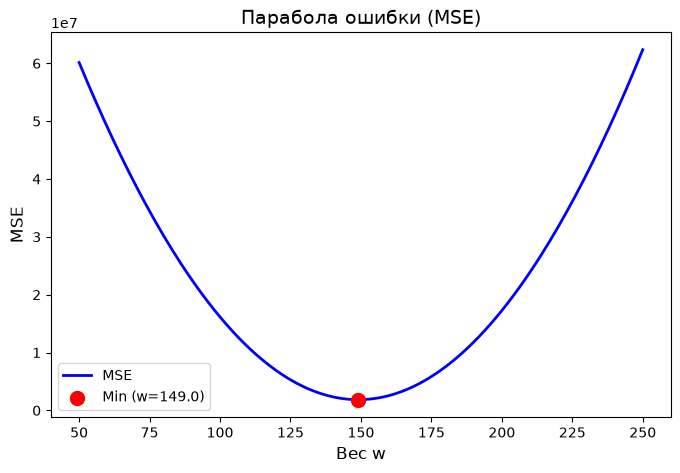

In [37]:
# 4
plt.figure(figsize = (8, 5))
plt.plot(w_list, mse_history, label='MSE', color='blue', linewidth=2)

plt.title("Парабола ошибки (MSE)", fontsize=14)
plt.xlabel("Вес w", fontsize=12)
plt.ylabel("MSE", fontsize=12)

plt.scatter(result_w, min_mse, color='red', s=100, zorder=5, label=f"Min (w={result_w})")
plt.legend()

plt.show()